<a href="https://colab.research.google.com/github/larevelyn/sp-urban-analytics/blob/main/notebooks/ANALISE_CRIMINALIDADE_SP_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Sincronizar pasta abaixo no seu drive: 
# https://drive.google.com/drive/folders/1-vwQv5PzO8vKrOakO0HuZTFYEP1o7_bZ?usp=sharing

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install unidecode python-calamine -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 38.6 MB/s eta 0:00:00


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import monotonically_increasing_id, split, trim, col, Column, coalesce, isnull, translate, round
from pyspark.sql.functions import avg, col, rand, when, lower, regexp_extract, regexp_replace, expr, create_map, lit
import pyspark.sql.functions as F
import pandas as pd
import geopandas as gpd
import unicodedata
from unidecode import unidecode
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import glob
from numpy import quantile
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
import numpy as np
import requests, io
from shapely import wkt

In [5]:
acentos = "áàãâäéèêëíìîïóòõôöúùûüçÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇ"
sem_acentos = "aaaaaeeeeiiiiooooouuuucAAAAAEEEEIIIIOOOOOUUUUC"

In [6]:
spark = SparkSession.builder \
    .appName("Analise Criminalidade SP") \
    .getOrCreate()

In [7]:
df_crimes = spark.read.parquet("drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/dados_criminais/dados_criminais.parquet")

In [8]:
df_crimes.show()

+--------------------+--------------------+--------------------+--------------------+--------------+------+------+-------------+------------------+------------------+------------+-------------------+------------------+--------------------+--------------------+-----------------+------------+------------+----------------------------+-------------------------------+----------------------------+----------------------------+--------------------+-------------+---------------+---------------+--------+--------+-----------+--------+-----------------+
|    NATUREZA_APURADA|   NOME_DEPARTAMENTO|      NOME_SECCIONAL|      NOME_DELEGACIA|NOME_MUNICIPIO|NUM_BO|ANO_BO|DATA_REGISTRO|DATA_OCORRENCIA_BO|HORA_OCORRENCIA_BO|DESC_PERIODO|    DESCR_TIPOLOCAL|DESCR_SUBTIPOLOCAL|              BAIRRO|          LOGRADOURO|NUMERO_LOGRADOURO|    LATITUDE|   LONGITUDE|NOME_DELEGACIA_CIRCUNSCRICAO|NOME_DEPARTAMENTO_CIRCUNSCRICAO|NOME_SECCIONAL_CIRCUNSCRICAO|NOME_MUNICIPIO_CIRCUNSCRICAO|             RUBRICA|DESCR_CO

In [9]:
# .groupBy('Categoria_Crime', 'NATUREZA_APURADA', 'ds_nome', "Região")

In [10]:
# https://repositorio.seade.gov.br/dataset/populacao-residente-municipio-de-sao-paulo
df_pop = (spark.read
          .option("header", "true")       
          .option("inferSchema", "true")  
          .option("encoding", "iso-8859-1")
          .option("delimiter", ";")        
          .csv("/content/drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/populacao/estimativa_pop_indicadores_msp.csv")
          .filter(col("ano") == 2024)
          .groupBy("distritos")
          .agg(F.sum("populacao").alias("populacao"))
          .withColumn("ds_nome", F.upper(F.translate(col("distritos"), acentos, sem_acentos))))

In [11]:
df_pop_crimes = (df_crimes_agg_bairro
                    .join(df_pop.select("ds_nome", "populacao"), on="ds_nome", how="left")
                    .groupBy("Região", "ds_nome", "populacao")
                    .agg(F.sum("QTD_CRIMES").alias("QTD_CRIMES"))
                    .withColumn("taxa_crimes", col("QTD_CRIMES") / col("populacao")))

NameError: name 'df_crimes_agg_bairro' is not defined

In [ ]:
df_pop_crimes_pd = gpd.GeoDataFrame(df_pop_crimes.toPandas()).merge(gdf_distritos, how="left", on='ds_nome')
df_pop_crimes_pd = df_pop_crimes_pd[['Região', 'ds_nome', 'populacao', 'QTD_CRIMES', 'taxa_crimes','geometry', 'centroid', 'centroid_x', 'centroid_y']]
df_pop_crimes_pd["crimes_norm"] = scaler.fit_transform(df_pop_crimes_pd[["taxa_crimes"]])


In [ ]:
def plotar_mapa(df, regiao):
    fig, ax = plt.subplots(figsize=(80, 80))
    df.plot(column="crimes_norm", cmap="Reds", legend=True,
                linewidth=0.6, edgecolor="black", ax=ax)

    # Normaliza os valores para mapear no colormap
    norm = mcolors.Normalize(vmin=df["crimes_norm"].min(),
                            vmax=df["crimes_norm"].max())
    cmap = cm.get_cmap("Reds")

    for x, y, label, valor in zip(df["centroid_x"],
                                df["centroid_y"],
                                df["Bairro_norm"],
                                df["crimes_norm"]):
        # Pega a cor RGBA do fundo daquele polígono
        r, g, b, _ = cmap(norm(valor))
        
        # Calcula luminância perceptual
        luminancia = 0.299 * r + 0.587 * g + 0.114 * b
        
        # Escuro → texto branco | Claro → texto preto
        cor_texto = "white" if luminancia < 0.3 else "black"
        
        ax.text(x, y, label, fontsize=9, ha="center", va="center",
                color=cor_texto)

    ax.set_title(f"Mapa de calor de criminalidade — Região {regiao}", fontsize=50)
    ax.set_axis_off()
    plt.show()


In [ ]:
df_pop_crimes_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Região       96 non-null     object  
 1   ds_nome      96 non-null     object  
 2   populacao    96 non-null     int64   
 3   QTD_CRIMES   96 non-null     int64   
 4   taxa_crimes  96 non-null     float64 
 5   geometry     96 non-null     geometry
 6   centroid     96 non-null     geometry
 7   centroid_x   96 non-null     float64 
 8   centroid_y   96 non-null     float64 
 9   crimes_norm  96 non-null     float64 
dtypes: float64(4), geometry(2), int64(2), object(2)
memory usage: 7.6+ KB


AttributeError: Line2D.set() got an unexpected keyword argument 'edgecolor'

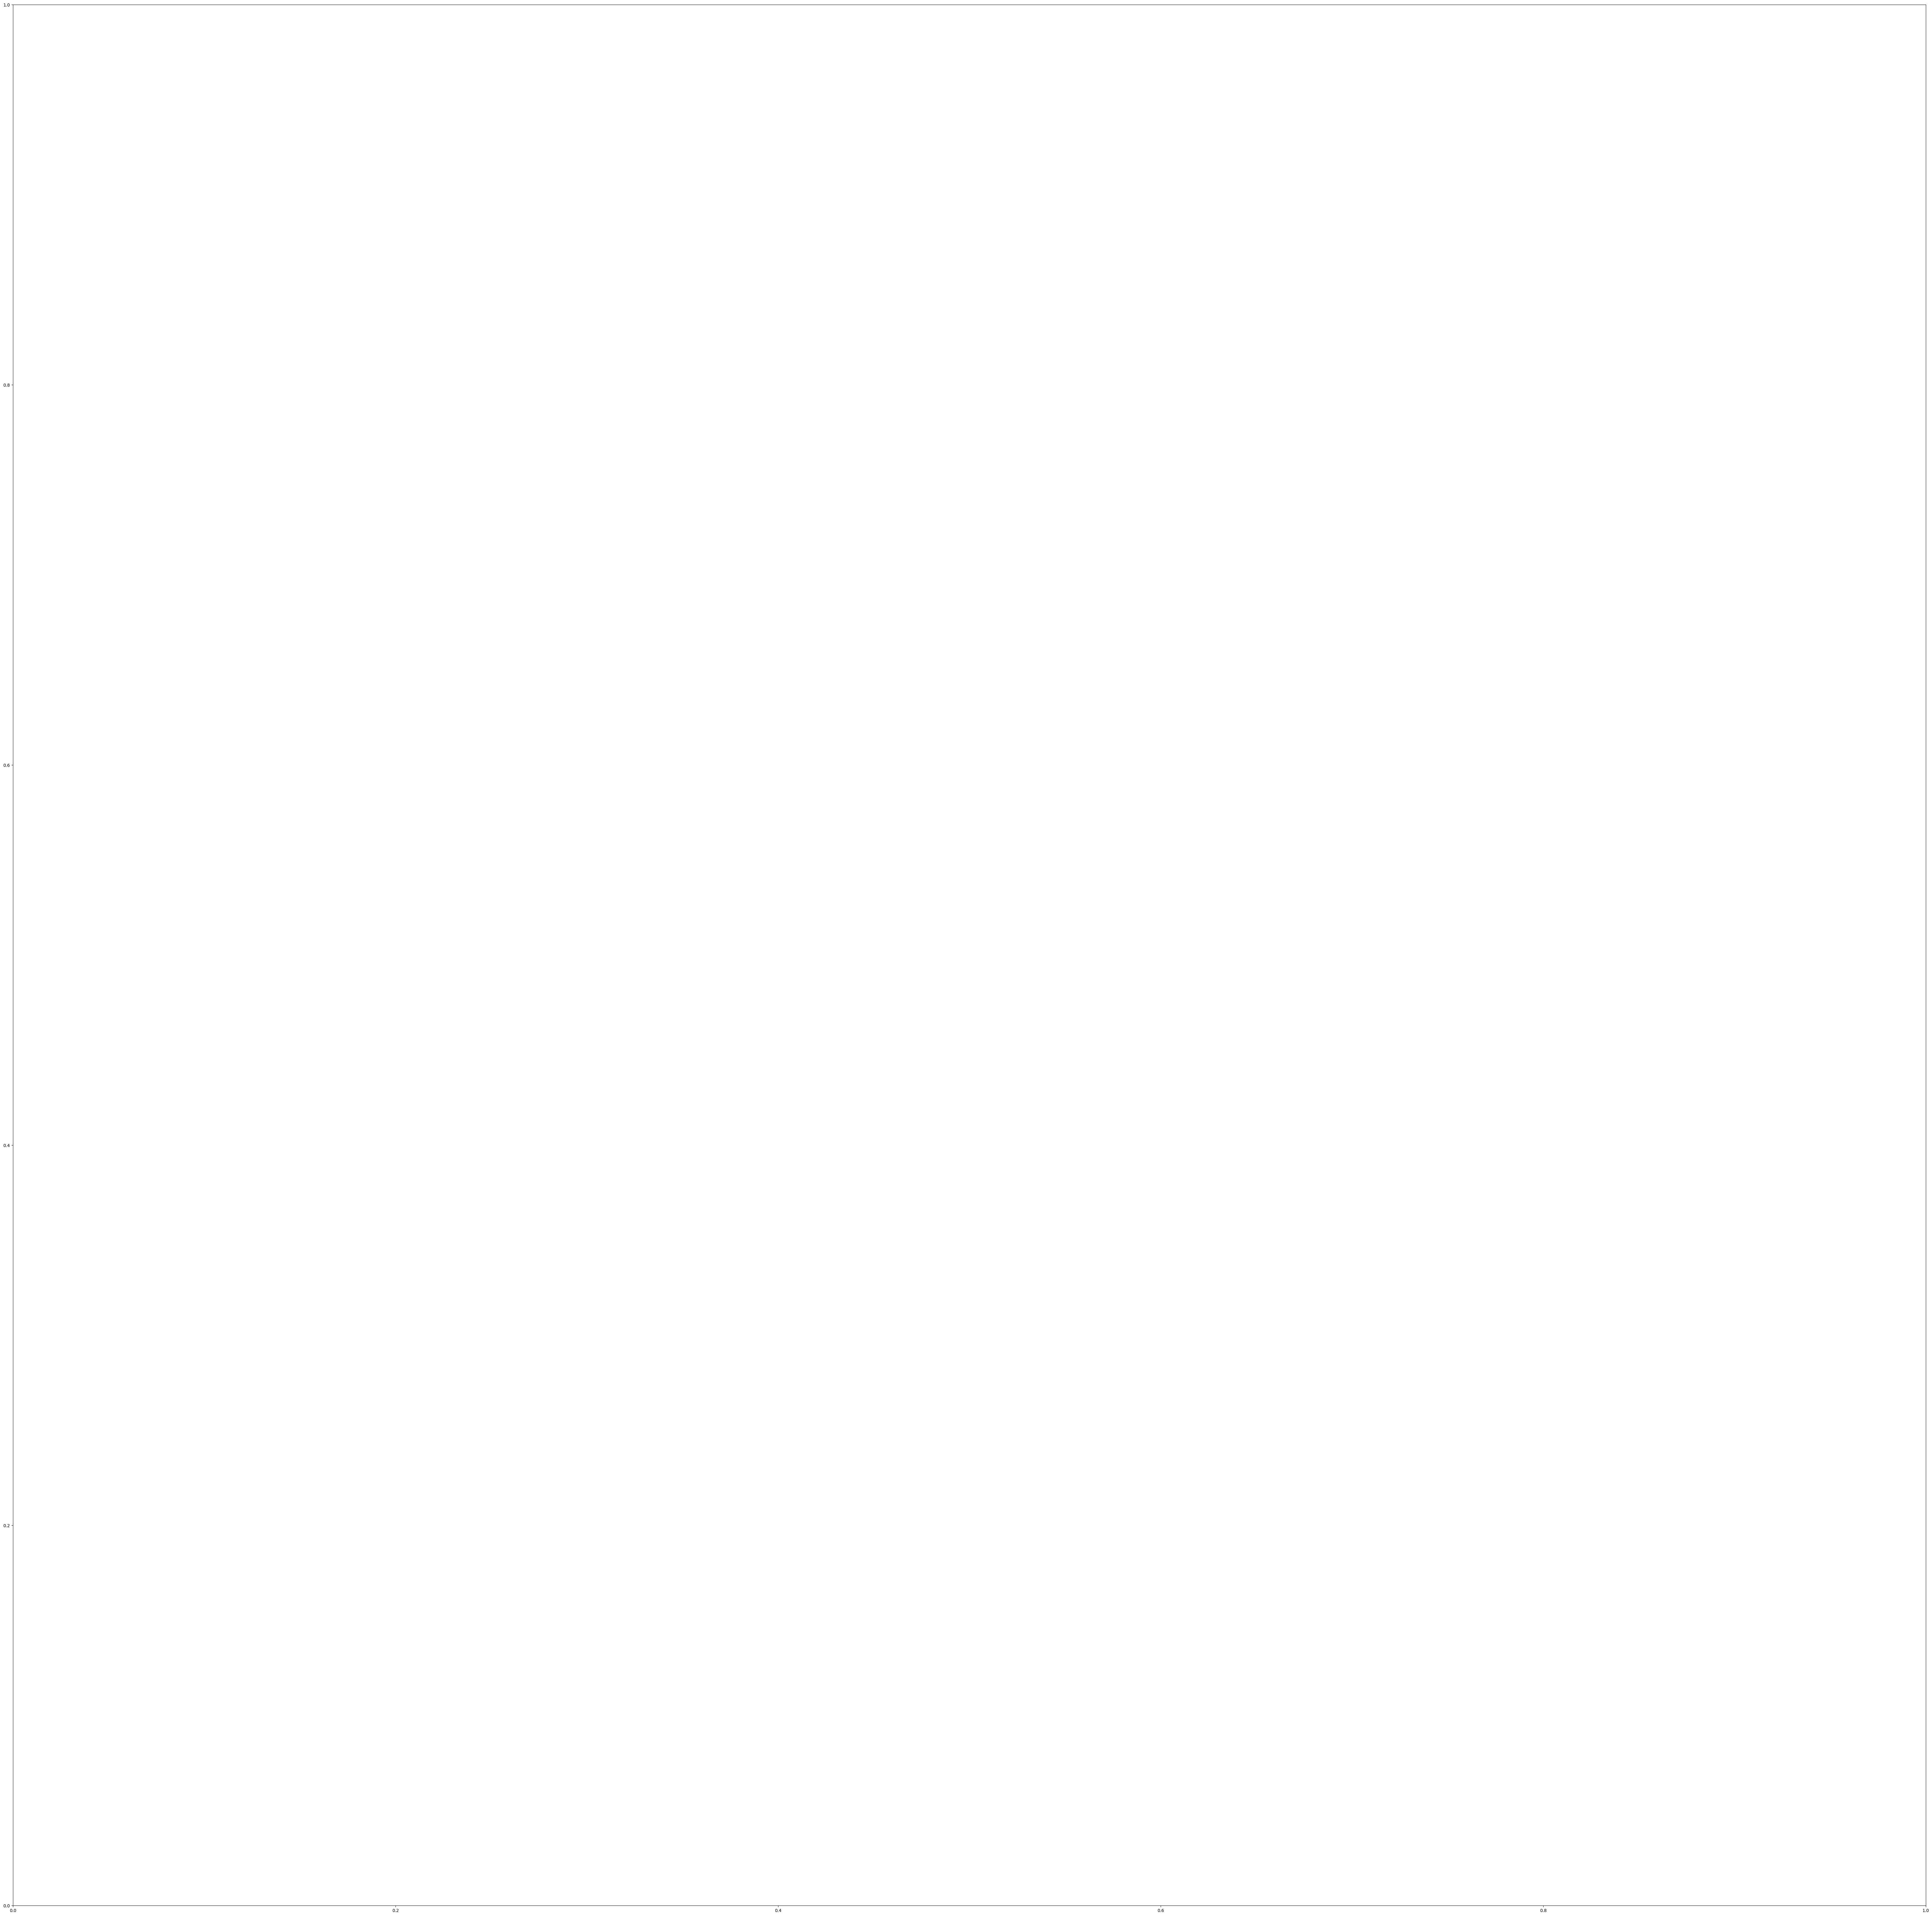

In [ ]:
plotar_mapa(df_pop_crimes_pd, "São Paulo")